In [1]:
import os
import torch
import torchvision
from torch.utils.data import random_split
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("itsahmad/indoor-scenes-cvpr-2019")

print("Path to dataset files:", path)

100%|██████████| 2.34G/2.34G [00:22<00:00, 112MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/itsahmad/indoor-scenes-cvpr-2019/versions/1


In [3]:
data_dir = os.path.join(path, "indoorCVPR_09", "Images")

In [4]:
classes = os.listdir(data_dir)
print(classes)
len(classes)

['library', 'hospitalroom', 'restaurant', 'nursery', 'concert_hall', 'dentaloffice', 'shoeshop', 'bar', 'fastfood_restaurant', 'waitingroom', 'museum', 'studiomusic', 'auditorium', 'pantry', 'kindergarden', 'garage', 'elevator', 'bakery', 'mall', 'lobby', 'laboratorywet', 'corridor', 'bookstore', 'movietheater', 'winecellar', 'deli', 'bathroom', 'classroom', 'cloister', 'restaurant_kitchen', 'kitchen', 'inside_bus', 'grocerystore', 'buffet', 'stairscase', 'clothingstore', 'operating_room', 'computerroom', 'videostore', 'bowling', 'dining_room', 'artstudio', 'office', 'toystore', 'casino', 'poolinside', 'laundromat', 'jewelleryshop', 'warehouse', 'hairsalon', 'children_room', 'bedroom', 'greenhouse', 'closet', 'locker_room', 'livingroom', 'florist', 'gym', 'subway', 'meeting_room', 'church_inside', 'prisoncell', 'gameroom', 'inside_subway', 'trainstation', 'tv_studio', 'airport_inside']


67

In [5]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

transformations = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])

dataset = ImageFolder(data_dir, transform = transformations)

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

def show_sample(img, label):
    print("Label:", dataset.classes[label], "(Class No: "+ str(label) + ")")
    plt.imshow(img.permute(1, 2, 0))

In [7]:
random_seed = 42
torch.manual_seed(random_seed)

In [8]:
train_ds, val_ds, test_ds = random_split(dataset, [13000, 2000, 620])
len(train_ds), len(val_ds), len(test_ds)

(13000, 2000, 620)

In [10]:
from torch.utils.data.dataloader import DataLoader
batch_size = 64

In [11]:
train_dl = DataLoader(train_ds, batch_size, shuffle = True, num_workers = 4, pin_memory = True)
val_dl = DataLoader(val_ds, batch_size*2, num_workers = 4, pin_memory = True)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [12]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images, nrow = 16).permute(1, 2, 0))
        break

In [13]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch {}: train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch+1, result['train_loss'], result['val_loss'], result['val_acc']))

In [14]:
from torchvision.models import ResNet18_Weights
class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, len(dataset.classes))

    def forward(self, xb):
        return torch.sigmoid(self.network(xb))

model = ResNet()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s]


In [15]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [16]:
device = get_default_device()
device

device(type='cuda')

In [17]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device)

ResNet(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runn

In [18]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [19]:
model = to_device(ResNet(), device)

In [20]:
evaluate(model, val_dl)

{'val_loss': 4.221888065338135, 'val_acc': 0.01113281212747097}

In [21]:
num_epochs = 16
opt_func = torch.optim.Adam
lr = 6e-5

history = fit(num_epochs, lr, model, train_dl, val_dl, opt_func)

Epoch 1: train_loss: 3.8145, val_loss: 3.6089, val_acc: 0.5332
Epoch 2: train_loss: 3.5274, val_loss: 3.4893, val_acc: 0.6325
Epoch 3: train_loss: 3.4220, val_loss: 3.4467, val_acc: 0.6685
Epoch 4: train_loss: 3.3588, val_loss: 3.4281, val_acc: 0.6980
Epoch 5: train_loss: 3.3191, val_loss: 3.4229, val_acc: 0.7183
Epoch 6: train_loss: 3.2950, val_loss: 3.4258, val_acc: 0.7259
Epoch 7: train_loss: 3.2796, val_loss: 3.4366, val_acc: 0.7257
Epoch 8: train_loss: 3.2683, val_loss: 3.4397, val_acc: 0.7408
Epoch 9: train_loss: 3.2614, val_loss: 3.4446, val_acc: 0.7431
Epoch 10: train_loss: 3.2566, val_loss: 3.4504, val_acc: 0.7464
Epoch 11: train_loss: 3.2523, val_loss: 3.4518, val_acc: 0.7560
Epoch 12: train_loss: 3.2485, val_loss: 3.4588, val_acc: 0.7571
Epoch 13: train_loss: 3.2463, val_loss: 3.4639, val_acc: 0.7665
Epoch 14: train_loss: 3.2443, val_loss: 3.4734, val_acc: 0.7511
Epoch 15: train_loss: 3.2409, val_loss: 3.4757, val_acc: 0.7647
Epoch 16: train_loss: 3.2402, val_loss: 3.4831, v

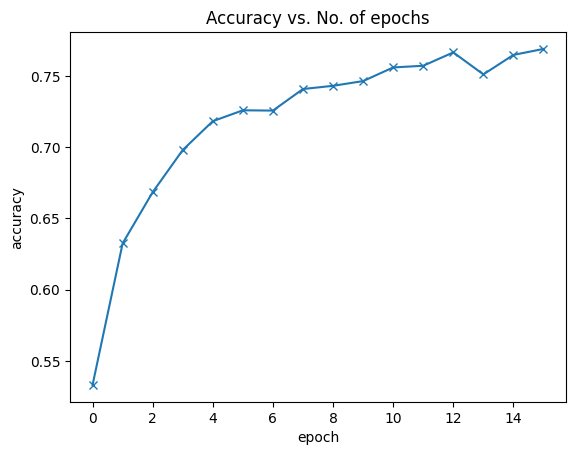

In [22]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

plot_accuracies(history)

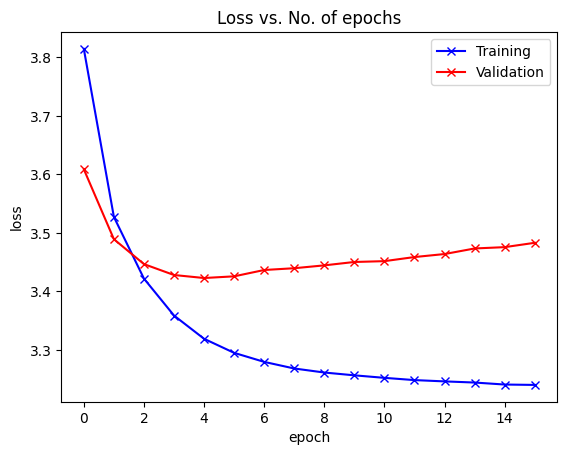

In [23]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

plot_losses(history)

In [25]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    prob, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return dataset.classes[preds[0].item()]

Label: library , Predicted: bookstore


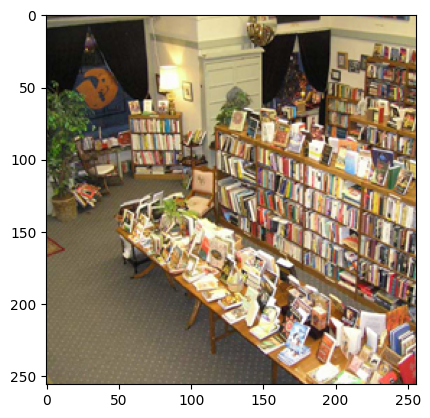

In [26]:
img, label = test_ds[10]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

In [27]:
# Save the model's state dictionary
torch.save(model.state_dict(), 'resnet18_16epochs_scene.pth')
print("Model saved successfully!")

Model saved successfully!


In [28]:
from google.colab import files
files.download('resnet18_16epochs_scene.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>